# COSC 2671/3047 — Assignment 2 | Group 8
## Notebook 3: NLP Analysis

Performs sentiment analysis and topic modelling on the English-only toot subset.

**Part 1 — Sentiment Analysis:** Applies VADER to score each toot. Analyses 
sentiment by snapshot and produces visualisations.

**Part 2 — Topic Modelling:** Preprocesses text, trains a 5-topic LDA model, 
assigns topics to toots, and generates word clouds and topic evolution charts.

**Input:** mastodon_data_clean/toots_english.csv
**Output:** mastodon_data_nlp/
**Run after:** Notebook 2

In [1]:
# Importing required libraries and files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from collections import Counter
import re
import warnings
warnings.filterwarnings("ignore")

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

import nltk
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
nltk.download("stopwords")
nltk.download("punkt")

import gensim
import gensim.corpora as corpora
from gensim.models import CoherenceModel

# The 2 files needed for NLP processing
df_toots_en    = pd.read_csv("mastodon_data_clean/toots_english.csv")
df_users_clean = pd.read_csv("mastodon_data_network/users_with_centrality.csv")

SNAPSHOTS = [
    "Snapshot 1 — Peak Exodus (Oct–Dec 2022)",
    "Snapshot 2 — Post Settling (2023)",
    "Snapshot 3 — Current State (2024–2026)",
]

print(f"English toots: {len(df_toots_en):,}")
print(f"Columns: {list(df_toots_en.columns)}")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


English toots: 4,485
Columns: ['toot_id', 'original_toot_id', 'username', 'user_id', 'user_instance', 'user_followers', 'user_following', 'user_posts_total', 'user_joined', 'content_text', 'language', 'hashtags', 'reblogs_count', 'favourites_count', 'replies_count', 'in_reply_to_id', 'in_reply_to_account_id', 'is_boost', 'boosted_from_instance', 'boosted_user_id', 'created_at', 'source_instance', 'hashtag_searched', 'year_month', 'snapshot']


In [2]:
# Sentiment Analysis using VADER
sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    if not isinstance(text, str) or text.strip() == "":
        return 0.0
    return sia.polarity_scores(text)["compound"]

# labelling function to keep score
def label_sentiment(score):
    if score >= 0.05:    return "positive"
    elif score <= -0.05: return "negative"
    else:                return "neutral"

df_toots_en["vader_score"] = df_toots_en["content_text"].apply(get_sentiment)
df_toots_en["vader_label"] = df_toots_en["vader_score"].apply(label_sentiment)

print("=== OVERALL SENTIMENT DISTRIBUTION ===")
print(df_toots_en["vader_label"].value_counts())
print(f"\nAverage compound score: {df_toots_en['vader_score'].mean():.4f}")

print("\n=== SENTIMENT BY SNAPSHOT ===")
for snap in SNAPSHOTS:
    subset = df_toots_en[df_toots_en["snapshot"] == snap]
    if len(subset) == 0:
        continue
    counts = subset["vader_label"].value_counts()
    total  = len(subset)
    avg    = subset["vader_score"].mean()
    print(f"\n{snap.split('—')[0].strip()}")
    print(f"  Positive: {counts.get('positive',0):>4} ({100*counts.get('positive',0)/total:.1f}%)")
    print(f"  Neutral:  {counts.get('neutral',0):>4}  ({100*counts.get('neutral',0)/total:.1f}%)")
    print(f"  Negative: {counts.get('negative',0):>4} ({100*counts.get('negative',0)/total:.1f}%)")
    print(f"  Avg score: {avg:.4f}")

=== OVERALL SENTIMENT DISTRIBUTION ===
vader_label
positive    2502
negative    1051
neutral      932
Name: count, dtype: int64

Average compound score: 0.2372

=== SENTIMENT BY SNAPSHOT ===

Snapshot 1
  Positive:  394 (65.1%)
  Neutral:   109  (18.0%)
  Negative:  102 (16.9%)
  Avg score: 0.4019

Snapshot 2
  Positive: 1087 (54.4%)
  Neutral:   394  (19.7%)
  Negative:  516 (25.8%)
  Avg score: 0.2109

Snapshot 3
  Positive: 1021 (54.2%)
  Neutral:   429  (22.8%)
  Negative:  433 (23.0%)
  Avg score: 0.2121


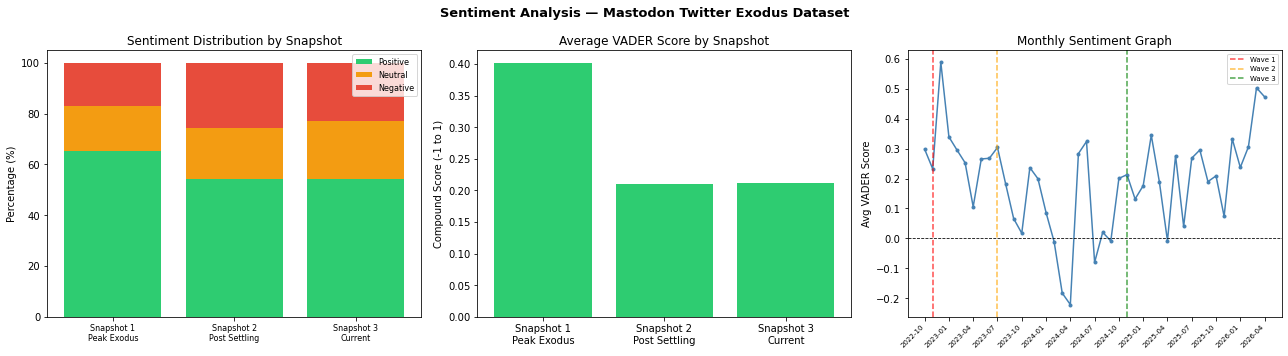

In [4]:
# Sentiment Analysis Plots
import os
os.makedirs("mastodon_data_nlp", exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

snap_labels = ["Snapshot 1\nPeak Exodus", 
               "Snapshot 2\nPost Settling", 
               "Snapshot 3\nCurrent"]

# Plot 1 — Stacked bar sentiment per snapshot
pos_vals, neu_vals, neg_vals = [], [], []
for snap in SNAPSHOTS:
    subset = df_toots_en[df_toots_en["snapshot"] == snap]
    total  = len(subset)
    counts = subset["vader_label"].value_counts()
    pos_vals.append(100 * counts.get("positive", 0) / total)
    neu_vals.append(100 * counts.get("neutral",  0) / total)
    neg_vals.append(100 * counts.get("negative", 0) / total)

x = range(3)
axes[0].bar(x, pos_vals, label="Positive", color="#2ECC71")
axes[0].bar(x, neu_vals, bottom=pos_vals, label="Neutral", color="#F39C12")
axes[0].bar(x, neg_vals,
            bottom=[p+n for p,n in zip(pos_vals, neu_vals)],
            label="Negative", color="#E74C3C")
axes[0].set_xticks(x)
axes[0].set_xticklabels(snap_labels, fontsize=8)
axes[0].set_title("Sentiment Distribution by Snapshot")
axes[0].set_ylabel("Percentage (%)")
axes[0].legend(fontsize=8)

# Plot 2 — Average VADER score per snapshot
avg_scores = [df_toots_en[df_toots_en["snapshot"]==s]["vader_score"].mean()
              for s in SNAPSHOTS]
bar_colors = ["#E74C3C" if s < 0 else "#2ECC71" for s in avg_scores]
axes[1].bar(snap_labels, avg_scores, color=bar_colors)
axes[1].axhline(y=0, color="black", linestyle="--", linewidth=0.8)
axes[1].set_title("Average VADER Score by Snapshot")
axes[1].set_ylabel("Compound Score (-1 to 1)")

# Plot 3 — Monthly sentiment arc
monthly_sentiment = df_toots_en.groupby("year_month")["vader_score"].mean()
axes[2].plot(range(len(monthly_sentiment)), monthly_sentiment.values,
             color="steelblue", linewidth=1.5, marker="o", markersize=3)
axes[2].axhline(y=0, color="black", linestyle="--", linewidth=0.8)
axes[2].set_xticks(range(0, len(monthly_sentiment), 3))
axes[2].set_xticklabels(monthly_sentiment.index[::3],
                         rotation=45, ha="right", fontsize=7)
axes[2].set_title("Monthly Sentiment Graph")
axes[2].set_ylabel("Avg VADER Score")

month_list = list(monthly_sentiment.index)
for ym, color, label in [
    ("2022-11", "red",    "Wave 1"),
    ("2023-07", "orange", "Wave 2"),
    ("2024-11", "green",  "Wave 3"),
]:
    if ym in month_list:
        axes[2].axvline(x=month_list.index(ym), color=color,
                        linestyle="--", alpha=0.7, label=label)
axes[2].legend(fontsize=7)

plt.suptitle("Sentiment Analysis — Mastodon Twitter Exodus Dataset",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("mastodon_data_nlp/sentiment_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

In [5]:
# LDA Preprocessing

# Adding custom stopwords to also filter common words in this dataset
STOP_WORDS = set(stopwords.words("english"))
CUSTOM_STOPS = {
    "twitter", "mastodon", "https", "http", "amp", "rt",
    "t", "co", "www", "just", "like", "get", "one", "know",
    "think", "use", "make", "also", "people", "user", "users",
    "social", "media", "platform", "account", "post", "toot",
    "will", "would", "really", "going", "time", "new", "good",
    "want", "need", "thing", "way", "back", "still", "even",
    "much", "well", "say", "said", "go", "see", "got", "come","best"
}
STOP_WORDS.update(CUSTOM_STOPS)

# Lemmatization
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    if not isinstance(text, str):
        return []
    # Remove URLs, mentions, hashtags
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#\w+", "", text)
    text = text.lower()
    tokens = word_tokenize(text)
    tokens = [
        lemmatizer.lemmatize(t)
        for t in tokens
        if t.isalpha()
        and len(t) > 2
        and t not in STOP_WORDS
    ]
    return tokens

# Applying all cleaning at once
df_toots_en["tokens"] = df_toots_en["content_text"].apply(preprocess)

# Remove toots with no tokens after preprocessing
df_toots_lda = df_toots_en[df_toots_en["tokens"].map(len) > 0].copy()
print(f"Toots with tokens: {len(df_toots_lda):,}")

# Sanity check — verifying preprocessing is working correctly
print("\nSample preprocessing check:")
for i in range(3):
    print(f"  Original: {df_toots_lda['content_text'].iloc[i][:80]}")
    print(f"  Tokens:   {df_toots_lda['tokens'].iloc[i][:10]}")
    print()

Toots with tokens: 4,483

Sample preprocessing check:
  Original: In the  # Fediverse  there are now  717 media accounts federated by  @ Flipboard
  Tokens:   ['fediverse', 'account', 'federated', 'flipboard', 'active', 'today', 'account', 'active', 'today', 'tapasmagazine']

  Original: In the  # Fediverse  there are now  717 media accounts federated by  @ Flipboard
  Tokens:   ['fediverse', 'account', 'federated', 'flipboard', 'active', 'today', 'account', 'active', 'today', 'narcitycanada']

  Original: Thanks  @ europeelects  for advertising the  # fediverse  on  # XTwitter ! «Euro
  Tokens:   ['thanks', 'europeelects', 'advertising', 'fediverse', 'xtwitter', 'europe', 'elect', 'currently', 'posting', 'due']



Dictionary: 2,970 unique tokens
Corpus:     4,483 documents

=== LDA TOPICS (n=5) ===

Topic 1: birdsite | bird | deletetwitter | musk | tweet | elon | twittertakeover | elonmusk | art | painting
Topic 2: newtomastodon | follow | introduction | year | instance | twittertakeover | fediverse | many | twittermigration | lot
Topic 3: fediverse | thread | twitterexodus | twitterrefugee | johnmastodon | iammastodon | active | account | today | find
Topic 4: app | start | newtomastodon | follow | welcome | find | enough | away | many | right
Topic 5: elonmusk | twittertakeover | deletetwitter | musk | socialmedia | elon | riptwitter | xcorp | site | year

=== TOPIC DISTRIBUTION ===
dominant_topic
0     877
1    1387
2     704
3     391
4    1124


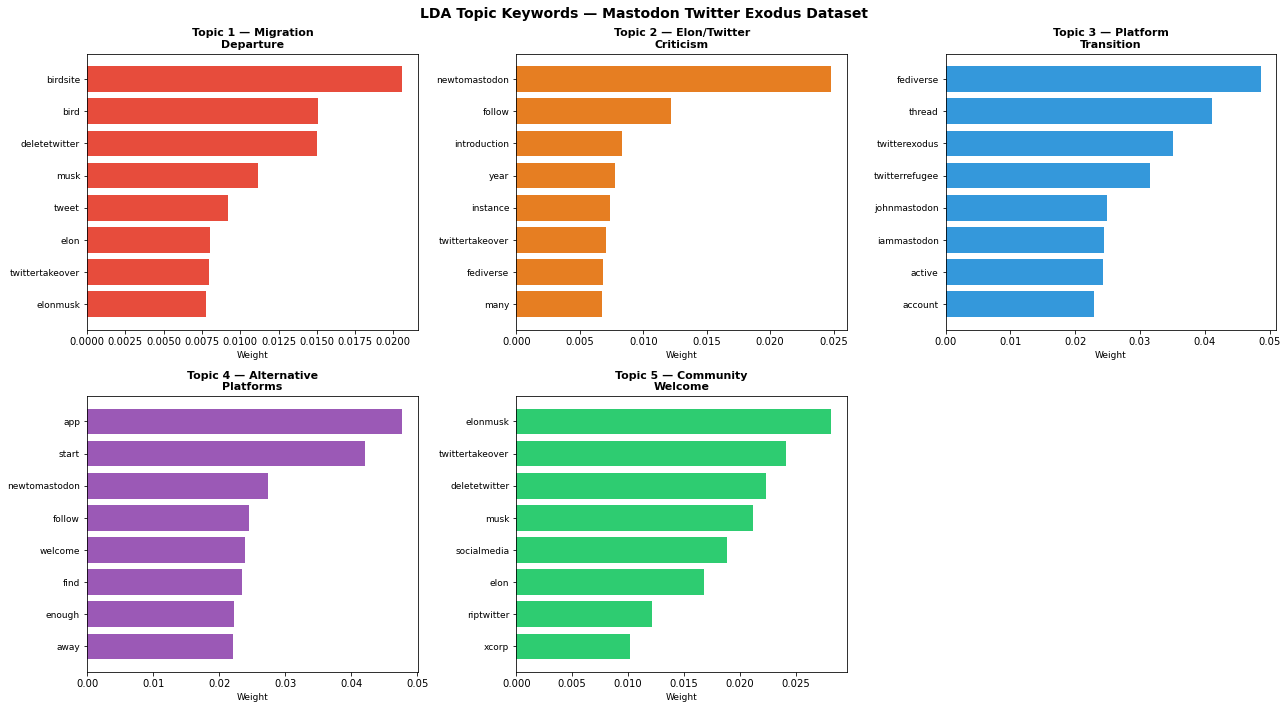

In [6]:
# Building dictionary and corpus
dictionary = corpora.Dictionary(df_toots_lda["tokens"])
dictionary.filter_extremes(no_below=5, no_above=0.5)
corpus     = [dictionary.doc2bow(tokens) for tokens in df_toots_lda["tokens"]]

print(f"Dictionary: {len(dictionary):,} unique tokens")
print(f"Corpus:     {len(corpus):,} documents")

# Training LDA with 5 topics
optimal_topics = 5

lda_model = gensim.models.LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=optimal_topics,
    random_state=42,
    passes=15,
    alpha="auto"
)

print(f"\n=== LDA TOPICS (n={optimal_topics}) ===\n")
for idx, topic in lda_model.print_topics(num_words=10):
    words = [w.split("*")[1].replace('"','').strip()
             for w in topic.split("+")]
    print(f"Topic {idx+1}: {' | '.join(words)}")

# Assigning dominant topic to each toot
def get_dominant_topic(tokens):
    bow    = dictionary.doc2bow(tokens)
    topics = lda_model.get_document_topics(bow)
    if not topics:
        return -1
    return max(topics, key=lambda x: x[1])[0]

df_toots_lda["dominant_topic"] = df_toots_lda["tokens"].apply(get_dominant_topic)

print(f"\n=== TOPIC DISTRIBUTION ===")
print(df_toots_lda["dominant_topic"].value_counts().sort_index().to_string())

# Plotting to visualise topic keywords as bar charts
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()  # flatten to easily index 0-4

topic_names = [
    "Migration\nDeparture",
    "Elon/Twitter\nCriticism",
    "Platform\nTransition",
    "Alternative\nPlatforms",
    "Community\nWelcome"
]

colors = ["#E74C3C", "#E67E22", "#3498DB", "#9B59B6", "#2ECC71"]

for idx in range(5):
    topic_terms = lda_model.show_topic(idx, topn=8)
    words  = [t[0] for t in topic_terms]
    scores = [t[1] for t in topic_terms]

    axes[idx].barh(words[::-1], scores[::-1], color=colors[idx])
    axes[idx].set_title(f"Topic {idx+1} — {topic_names[idx]}",
                        fontsize=11, fontweight="bold")
    axes[idx].set_xlabel("Weight", fontsize=9)
    axes[idx].tick_params(axis='y', labelsize=9)

# Hide the 6th subplot - empty since we only have 5 topics
axes[5].set_visible(False)

plt.suptitle("LDA Topic Keywords — Mastodon Twitter Exodus Dataset",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("mastodon_data_nlp/lda_topics.png", dpi=150, bbox_inches="tight")
plt.show()

=== TOPIC DISTRIBUTION BY SNAPSHOT ===

                                         T1: Onboarding  T2: Elon Criticism  T3: Migration  T4: Fediverse Identity  T5: Twitter Grief
snapshot                                                                                                                             
Snapshot 1 — Peak Exodus (Oct–Dec 2022)            12.9                53.6            3.0                    20.5               10.1
Snapshot 2 — Post Settling (2023)                  15.4                30.5           20.7                     4.5               28.9
Snapshot 3 — Current State (2024–2026)             26.2                24.1           14.5                     9.5               25.8


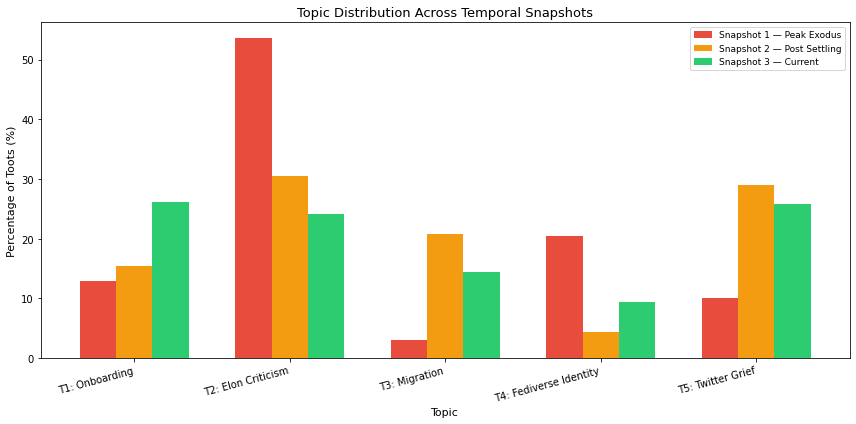

In [7]:
# Plots to show topic evolution across the three snapshots
print("=== TOPIC DISTRIBUTION BY SNAPSHOT ===\n")

topic_snapshot = pd.crosstab(
    df_toots_lda["snapshot"],
    df_toots_lda["dominant_topic"],
    normalize="index"
) * 100

# Renaming columns to topic labels
topic_snapshot.columns = [
    "T1: Onboarding",
    "T2: Elon Criticism",
    "T3: Migration",
    "T4: Fediverse Identity",
    "T5: Twitter Grief"
]

print(topic_snapshot.round(1).to_string())

fig, ax = plt.subplots(figsize=(12, 6))
topic_snapshot.T.plot(
    kind="bar", ax=ax,
    color=["#E74C3C", "#F39C12", "#2ECC71"],
    width=0.7
)
ax.set_xlabel("Topic", fontsize=11)
ax.set_ylabel("Percentage of Toots (%)", fontsize=11)
ax.set_title("Topic Distribution Across Temporal Snapshots", fontsize=13)
ax.legend([
    "Snapshot 1 — Peak Exodus",
    "Snapshot 2 — Post Settling",
    "Snapshot 3 — Current"
], fontsize=9)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig("mastodon_data_nlp/topic_evolution.png", dpi=150)
plt.show()

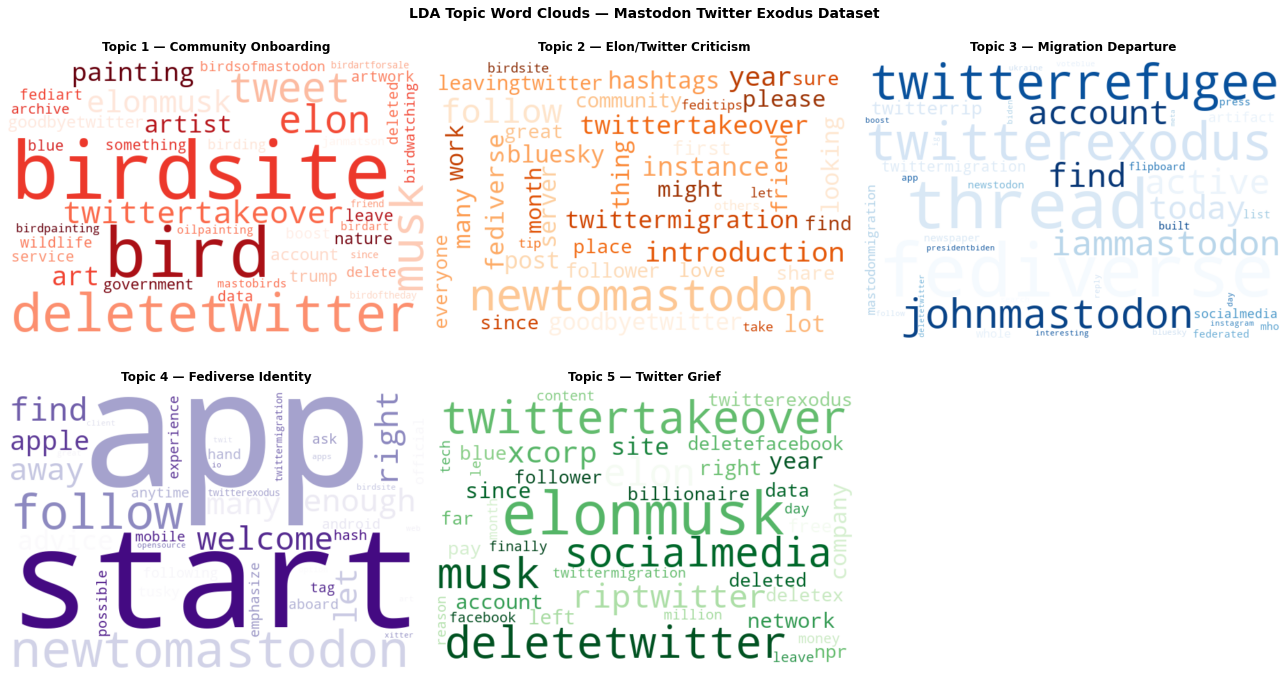

In [8]:
# Word Cloud Generation
from wordcloud import WordCloud

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

topic_names = [
    "Topic 1 — Community Onboarding",
    "Topic 2 — Elon/Twitter Criticism",
    "Topic 3 — Migration Departure",
    "Topic 4 — Fediverse Identity",
    "Topic 5 — Twitter Grief"
]

colors = ["Reds", "Oranges", "Blues", "Purples", "Greens"]

for idx in range(5):
    topic_terms = dict(lda_model.show_topic(idx, topn=50))
    
    wc = WordCloud(
        width=600, height=400,
        background_color="white",
        colormap=colors[idx],
        max_words=40,
        prefer_horizontal=0.9
    ).generate_from_frequencies(topic_terms)
    
    axes[idx].imshow(wc, interpolation="bilinear")
    axes[idx].axis("off")
    axes[idx].set_title(topic_names[idx], fontsize=12, fontweight="bold", pad=10)

# Hiding 6th subplot
axes[5].set_visible(False)

plt.suptitle("LDA Topic Word Clouds — Mastodon Twitter Exodus Dataset",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("mastodon_data_nlp/wordclouds_topics.png", dpi=150, bbox_inches="tight")
plt.show()